In [ ]:
import pandas as pd

df_feb = pd.read_parquet("yellow_tripdata_2025-02.parquet")
df_mar = pd.read_parquet("yellow_tripdata_2025-03.parquet")
df_apr = pd.read_parquet("yellow_tripdata_2025-04.parquet")

df = pd.concat([df_feb, df_mar, df_apr], ignore_index=True)

In [ ]:
df = df.dropna(subset=[
    'tpep_pickup_datetime',
    'tpep_dropoff_datetime',
    'trip_distance',
    'fare_amount'
])

# Convert datetime
df['tpep_pickup_datetime'] = pd.to_datetime(df['tpep_pickup_datetime'])
df['tpep_dropoff_datetime'] = pd.to_datetime(df['tpep_dropoff_datetime'])

# Remove invalid trips
df = df[df['tpep_dropoff_datetime'] > df['tpep_pickup_datetime']]
df = df[df['trip_distance'] > 0]
df = df[df['fare_amount'] > 0]

# Remove extreme garbage
df = df[df['trip_distance'] < 100]

In [ ]:
df['trip_duration'] = (
    df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime']
).dt.total_seconds() / 60

df['tip_percentage'] = df['tip_amount'] / df['fare_amount']

df['pickup_hour'] = df['tpep_pickup_datetime'].dt.hour
df['pickup_day'] = df['tpep_pickup_datetime'].dt.day_name()

df['is_night'] = ((df['pickup_hour'] >= 22) | (df['pickup_hour'] <= 4))

In [ ]:
zones = pd.read_csv("taxi_zone_lookup.csv")

df = df.merge(
    zones,
    left_on='PULocationID',
    right_on='LocationID',
    how='left'
)

In [ ]:
print(df.describe())
print(df['trip_duration'].quantile([0.01, 0.99]))


           VendorID        tpep_pickup_datetime       tpep_dropoff_datetime  \
count  1.080509e+07                    10805090                    10805090   
mean   1.783305e+00  2025-03-17 21:53:04.908188  2025-03-17 22:09:16.893910   
min    1.000000e+00         2007-12-05 18:45:00         2007-12-05 19:02:00   
25%    2.000000e+00  2025-02-23 18:33:11.250000         2025-02-23 18:49:21   
50%    2.000000e+00  2025-03-17 21:43:52.500000         2025-03-17 21:57:01   
75%    2.000000e+00         2025-04-08 21:17:08  2025-04-08 21:31:03.750000   
max    6.000000e+00         2025-05-01 00:48:13         2025-05-01 21:42:14   
std    4.139226e-01                         NaN                         NaN   

       passenger_count  trip_distance    RatecodeID  PULocationID  \
count     8.859044e+06   1.080509e+07  8.859044e+06  1.080509e+07   
mean      1.290035e+00   3.279451e+00  2.398240e+00  1.630724e+02   
min       0.000000e+00   1.000000e-02  1.000000e+00  1.000000e+00   
25%       1.

In [ ]:
df.to_parquet("nyc_taxi_cleaned.parquet")

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10805090 entries, 0 to 10805089
Data columns (total 29 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int32         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     object        
 7   PULocationID           int32         
 8   DOLocationID           int32         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  Airport_fee         

In [ ]:
from scipy.stats import ttest_ind

df['hour'] = df['tpep_pickup_datetime'].dt.hour

night = df[(df['hour'] >= 22) | (df['hour'] <= 4)]
day = df[(df['hour'] > 4) & (df['hour'] < 22)]

night_tips = night['tip_amount'] / night['fare_amount']
day_tips = day['tip_amount'] / day['fare_amount']

stat, p_value = ttest_ind(night_tips, day_tips, equal_var=False)

print(p_value)

1.0228601595974682e-151


In [ ]:
df['distance_bucket'] = pd.cut(df['trip_distance'], bins=[0,2,5,10,20,50])

grouped = df.groupby(['distance_bucket', 'is_night'])['tip_percentage'].mean()
print(grouped)

/tmp/ipykernel_6482/715688851.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby(['distance_bucket', 'is_night'])['tip_percentage'].mean()


distance_bucket  is_night
(0, 2]           False       0.223152
                 True        0.191597
(2, 5]           False       0.161430
                 True        0.132860
(5, 10]          False       0.143384
                 True        0.110080
(10, 20]         False       0.151048
                 True        0.127362
(20, 50]         False       0.140876
                 True        0.134988
Name: tip_percentage, dtype: float64


In [ ]:
df['pickup_hour_ts'] = df['tpep_pickup_datetime'].dt.floor('h')

hourly = df.groupby('pickup_hour_ts').agg({
    'trip_distance': 'count',   # trip volume
    'fare_amount': 'mean',
    'tip_percentage': 'mean',
    'trip_duration': 'mean'
}).rename(columns={'trip_distance': 'trip_count'}).reset_index()

In [ ]:
df['pickup_date'] = df['tpep_pickup_datetime'].dt.date

daily = df.groupby('pickup_date').agg({
    'trip_distance': 'count',
    'fare_amount': 'mean',
    'tip_percentage': 'mean'
}).rename(columns={'trip_distance': 'trip_count'}).reset_index()

In [ ]:
df['pickup_week'] = df['tpep_pickup_datetime'].dt.to_period('W')

weekly = df.groupby('pickup_week').agg({
    'trip_distance': 'count',
    'fare_amount': 'mean'
}).reset_index()

In [ ]:
hour_pattern = df.groupby(df['pickup_hour']).agg({
    'trip_distance': 'count',
    'fare_amount': 'mean'
}).rename(columns={'trip_distance': 'trip_count'})

In [ ]:
hour_pattern

,trip_count,fare_amount
pickup_hour,,
0,332346,19.253183
1,216415,17.787014
2,139780,17.173993
3,97133,18.098837
4,74736,22.942348
5,79408,25.865266
6,159911,22.264266
7,309747,19.658455
8,426848,18.387047


In [ ]:
dow_pattern = df.groupby(df['pickup_day']).agg({
    'trip_distance': 'count',
    'fare_amount': 'mean'
})

In [ ]:
dow_pattern

,trip_distance,fare_amount
pickup_day,,
Friday,1548158,18.824202
Monday,1288616,19.706189
Saturday,1812030,18.012279
Sunday,1467434,19.703420
Thursday,1586274,18.912531
Tuesday,1493662,18.696983
Wednesday,1608916,18.633184


In [ ]:
df['month'] = df['tpep_pickup_datetime'].dt.month

monthly_pattern = df.groupby(['month', 'pickup_hour']).agg({
    'trip_distance': 'count'
}).rename(columns={'trip_distance': 'trip_count'}).reset_index()

In [ ]:
monthly_pattern

,month,pickup_hour,trip_count
0,1,0,1
1,1,22,2
2,1,23,28
3,2,0,98846
4,2,1,65047
...,...,...,...
72,4,21,220899
73,4,22,207998
74,4,23,157000
75,5,0,3


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10805090 entries, 0 to 10805089
Data columns (total 35 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int32         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     object        
 7   PULocationID           int32         
 8   DOLocationID           int32         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  Airport_fee         

### Hourly Pattern Analysis

This plot visualizes the average trip count and fare amount by hour of the day. This helps identify peak and off-peak hours for taxi demand and pricing.

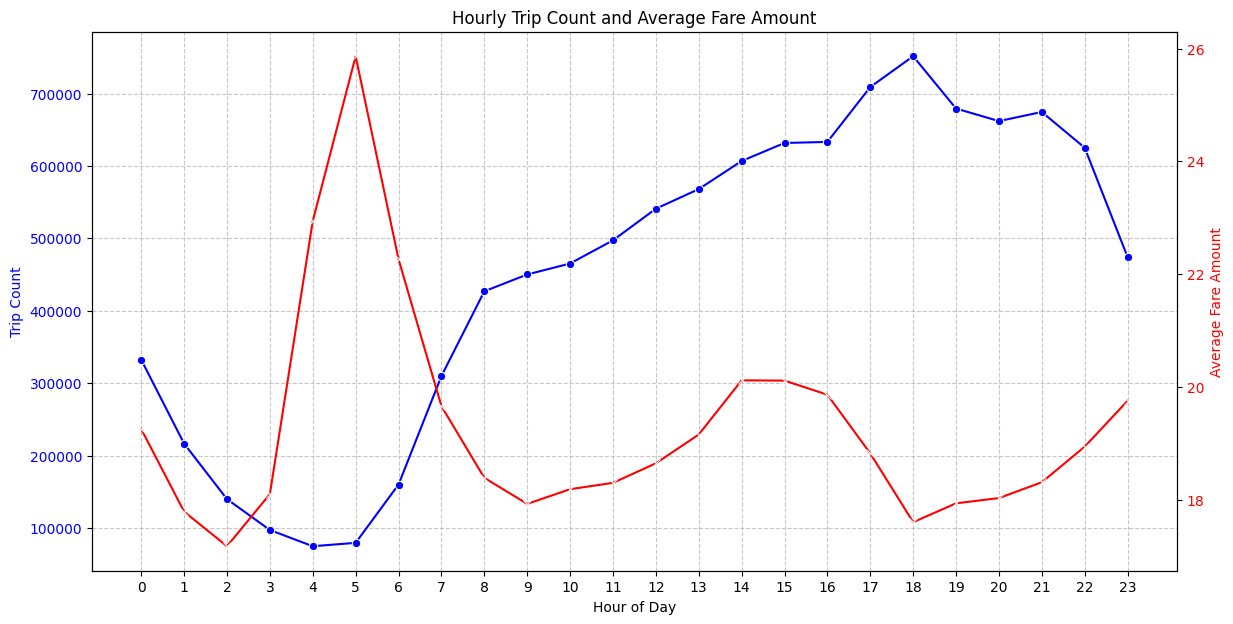

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax1 = plt.subplots(figsize=(14, 7))

# Plotting trip count
sns.lineplot(x=hour_pattern.index, y='trip_count', data=hour_pattern, marker='o', ax=ax1, color='blue')
ax1.set_xlabel('Hour of Day')
ax1.set_ylabel('Trip Count', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.set_title('Hourly Trip Count and Average Fare Amount')
ax1.grid(True, linestyle='--', alpha=0.7)

# Create a second y-axis for fare amount
ax2 = ax1.twinx()
sns.lineplot(x=hour_pattern.index, y='fare_amount', data=hour_pattern, marker='x', ax=ax2, color='red')
ax2.set_ylabel('Average Fare Amount', color='red')
ax2.tick_params(axis='y', labelcolor='red')

plt.xticks(range(0, 24))
plt.show()

### Day of Week Pattern Analysis

These bar charts illustrate the total trip count and average fare amount for each day of the week, revealing weekly trends in taxi usage and earnings.

/tmp/ipykernel_31431/1081670365.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=dow_pattern.index, y='trip_distance', data=dow_pattern, ax=axes[0], palette='viridis')
/tmp/ipykernel_31431/1081670365.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=dow_pattern.index, y='fare_amount', data=dow_pattern, ax=axes[1], palette='plasma')


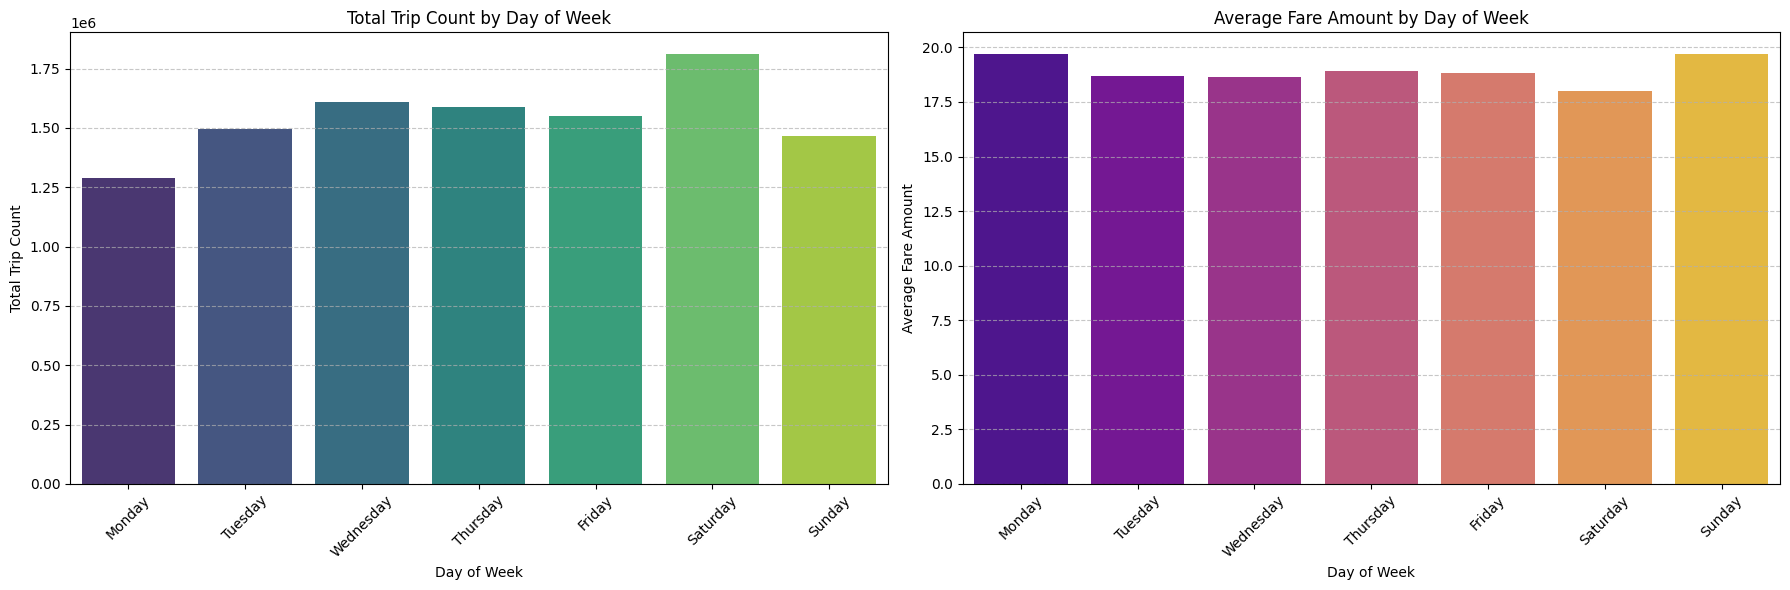

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure the days are in order for consistent plotting
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dow_pattern = dow_pattern.reindex(day_order)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Plotting trip count by day of week
sns.barplot(x=dow_pattern.index, y='trip_distance', data=dow_pattern, ax=axes[0], palette='viridis')
axes[0].set_xlabel('Day of Week')
axes[0].set_ylabel('Total Trip Count')
axes[0].set_title('Total Trip Count by Day of Week')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# Plotting average fare amount by day of week
sns.barplot(x=dow_pattern.index, y='fare_amount', data=dow_pattern, ax=axes[1], palette='plasma')
axes[1].set_xlabel('Day of Week')
axes[1].set_ylabel('Average Fare Amount')
axes[1].set_title('Average Fare Amount by Day of Week')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

### Monthly Hourly Trip Count Analysis

This visualization shows how the hourly trip count pattern changes across different months (February, March, April). Each line represents a month, allowing for comparison of demand trends over time.

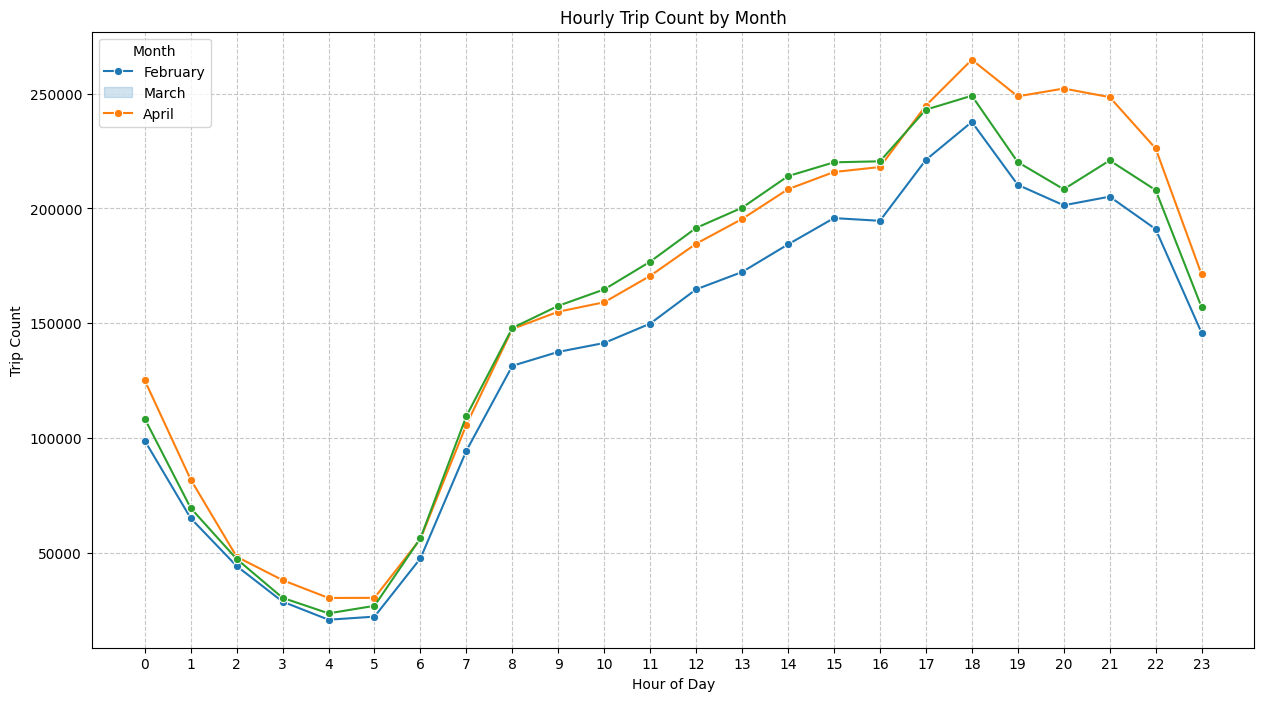

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter out sparse months if they exist (like 1 and 12 from the previous describe)
monthly_pattern_filtered = monthly_pattern[monthly_pattern['month'].isin([2, 3, 4])]

plt.figure(figsize=(15, 8))
sns.lineplot(x='pickup_hour', y='trip_count', hue='month', data=monthly_pattern_filtered, marker='o', palette='tab10')
plt.title('Hourly Trip Count by Month')
plt.xlabel('Hour of Day')
plt.ylabel('Trip Count')
plt.xticks(range(0, 24))
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Month', loc='upper left', labels=['February', 'March', 'April'])
plt.show()

In [ ]:
hourly_std = hourly.groupby(hourly['pickup_hour_ts'].dt.hour)['trip_count'].std()
hourly_mean = hourly.groupby(hourly['pickup_hour_ts'].dt.hour)['trip_count'].mean()

cv = hourly_std / hourly_mean

,trip_count
pickup_hour_ts,
0,0.783901
1,0.999406
2,1.122140
3,1.126310
4,0.798160
5,0.218352
6,0.279045
7,0.394986
8,0.363507


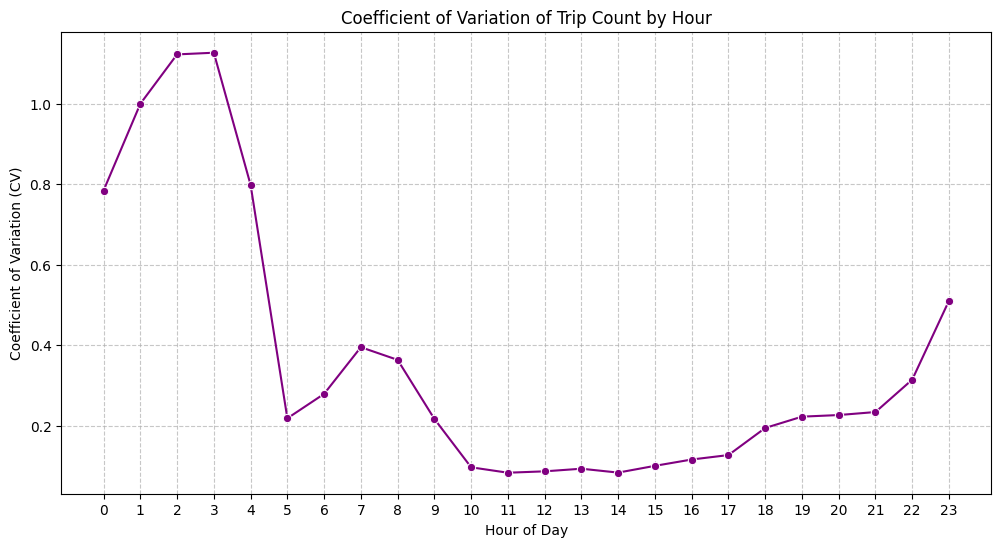

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.lineplot(x=cv.index, y=cv.values, marker='o', color='purple')
plt.title('Coefficient of Variation of Trip Count by Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Coefficient of Variation (CV)')
plt.xticks(range(0, 24))
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [ ]:
df['is_peak'] = df['pickup_hour'].isin([7,8,9,17,18,19,20])

df['sim_fare'] = df['fare_amount']
df.loc[df['is_peak'], 'sim_fare'] *= 1.15

# assume elasticity = -0.3
df['sim_trip_count'] = 1.0  # Initialize as float
df.loc[df['is_peak'], 'sim_trip_count'] *= (1 - 0.045)  # ~4.5% drop

In [ ]:
df.loc[df['is_peak'], 'sim_trip_count']

,sim_trip_count
13464,0.955
13466,0.955
13467,0.955
13468,0.955
13469,0.955
...,...
10800210,0.955
10800211,0.955
10800212,0.955
10800213,0.955
